# Spline-CLT vs Linear CLT: Wide-Expansion Comparison

Results from the `neurips_wide_gpt2` paper run.

**Variants:**
- **Spline-CLT (wide)**: KAN encoder, 16384 features (21x expansion) — seed 101
- **Linear CLT (wide)**: Linear encoder, 32768 features (43x expansion) — seed 101
- **Linear CLT (feat-match)**: Linear encoder, 16384 features (21x, matched) — seeds 101, 202, 303

Note: Seed coverage varies by variant. Plots handle this gracefully.

## 0. Configuration

In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Repo root ────────────────────────────────────────────────────���────────────
REPO_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), ".."))).resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── NeurIPS wide run root ─────────���──────────────────────────��───────────────
SUITE_ROOT = REPO_ROOT / "results" / "paper" / "neurips_wide_gpt2"
RUNS_ROOT  = SUITE_ROOT / "runs"
DATA_DIR   = str(SUITE_ROOT / "shared" / "activations" / "gpt2")

# ── Variants (dir name under runs/) ────────��─────────────────────────────────
VARIANTS = {
    "Spline-CLT (wide)":       "spline_wide_gpt2",
    "Linear CLT (wide)":       "linear_wide_gpt2",
    "Linear CLT (feat-match)": "linear_wide_feat_gpt2",
}

COLORS = {
    "Spline-CLT (wide)":       "steelblue",
    "Linear CLT (wide)":       "coral",
    "Linear CLT (feat-match)": "mediumseagreen",
}

# ── Discover available seeds per variant ───��──────────────────────────────────
AVAILABLE_SEEDS: dict[str, list[int]] = {}
for label, variant_dir in VARIANTS.items():
    vdir = RUNS_ROOT / variant_dir
    seeds = sorted(
        int(p.name.split("_")[1])
        for p in vdir.iterdir()
        if p.is_dir() and p.name.startswith("seed_")
    ) if vdir.exists() else []
    AVAILABLE_SEEDS[label] = seeds

ALL_SEEDS = sorted(set(s for seeds in AVAILABLE_SEEDS.values() for s in seeds))

# ── Interactive analysis settings ────���───────────────────────────────────���────
INTERACTIVE_SEED  = 101
PROMPT            = "The Eiffel Tower is located in"
MAX_FEATURES      = 64
RUN_SHAPLEY       = True
SHAPLEY_SAMPLES   = 64
N_SPLINE_FEATURES = 6

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.float32

print(f"Suite root : {SUITE_ROOT}")
print(f"Data dir   : {DATA_DIR}")
print(f"Device     : {DEVICE}")
print()
for label, seeds in AVAILABLE_SEEDS.items():
    print(f"  {label:<28} seeds: {seeds}")
print(f"\nAll seeds across variants: {ALL_SEEDS}")

Suite root : /home/sureshm/circuit-tracer/results/paper/neurips_wide_gpt2
Data dir   : /home/sureshm/circuit-tracer/results/paper/neurips_wide_gpt2/shared/activations/gpt2
Device     : cuda

  Spline-CLT (wide)            seeds: [101]
  Linear CLT (wide)            seeds: [101]
  Linear CLT (feat-match)      seeds: [101, 202, 303]

All seeds across variants: [101, 202, 303]


## 1. Load All Evaluation Summaries

Read the pre-computed `evaluation_summary.json` for every variant x seed.

In [2]:
# summaries[label][seed] = evaluation_summary dict
summaries: dict[str, dict[int, dict]] = {}

for label, variant_dir in VARIANTS.items():
    summaries[label] = {}
    for seed in AVAILABLE_SEEDS[label]:
        path = RUNS_ROOT / variant_dir / f"seed_{seed}" / "evaluation" / "evaluation_summary.json"
        if not path.exists():
            print(f"  [MISSING] {label} seed={seed}: {path}")
            continue
        with open(path) as f:
            summaries[label][seed] = json.load(f)
        r = summaries[label][seed]["reconstruction"]
        print(f"  {label:<28} seed={seed}  "
              f"MSE={r['mse_total']:.4f}  "
              f"cos_sim={r['cosine_similarity']:.4f}  "
              f"rel_err={r['relative_error']:.4f}")

total = sum(len(v) for v in summaries.values())
expected = sum(len(s) for s in AVAILABLE_SEEDS.values())
print(f"\nLoaded {total}/{expected} summaries.")

  Spline-CLT (wide)            seed=101  MSE=1.5130  cos_sim=0.2063  rel_err=0.4639
  Linear CLT (wide)            seed=101  MSE=354.8774  cos_sim=0.0477  rel_err=7.1059
  Linear CLT (feat-match)      seed=101  MSE=214.0727  cos_sim=0.0555  rel_err=5.5193
  Linear CLT (feat-match)      seed=202  MSE=215.5345  cos_sim=0.0552  rel_err=5.5341
  [MISSING] Linear CLT (feat-match) seed=303: /home/sureshm/circuit-tracer/results/paper/neurips_wide_gpt2/runs/linear_wide_feat_gpt2/seed_303/evaluation/evaluation_summary.json

Loaded 4/5 summaries.


## 2. Reconstruction Quality

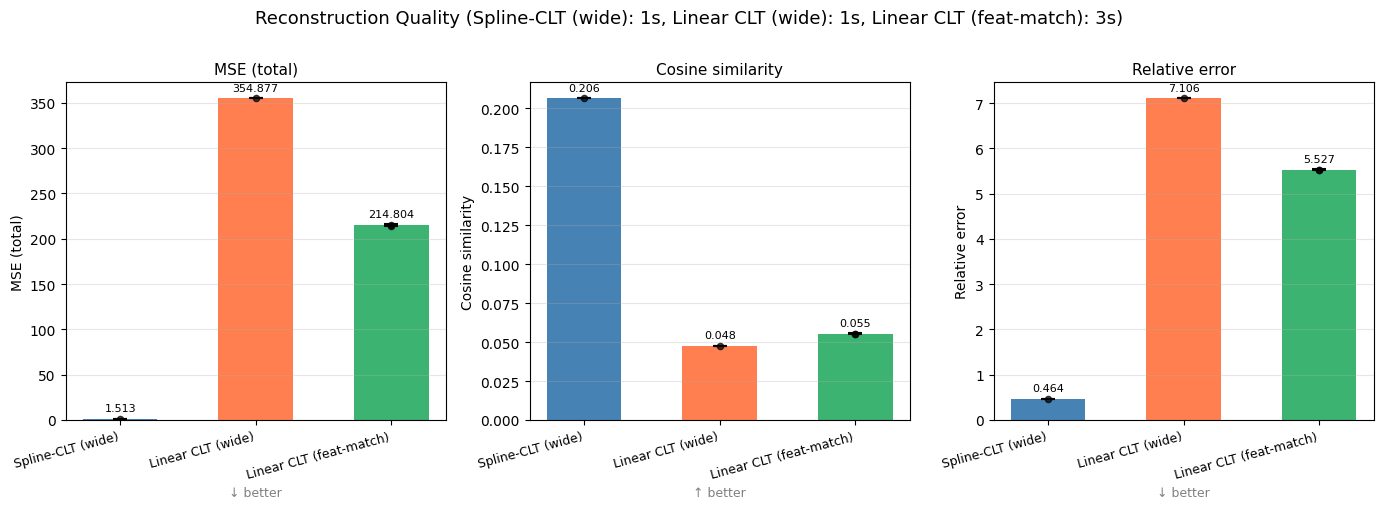

In [3]:
def recon_values(label: str, key: str) -> list[float]:
    return [summaries[label][s]["reconstruction"][key]
            for s in AVAILABLE_SEEDS[label] if s in summaries[label]]

recon_cfg = [
    ("MSE (total)",       "mse_total",         True),
    ("Cosine similarity", "cosine_similarity",  False),
    ("Relative error",    "relative_error",     True),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
x = np.arange(len(VARIANTS))

for ax, (title, key, lower_better) in zip(axes, recon_cfg):
    means = [np.mean(recon_values(lbl, key)) for lbl in VARIANTS]
    stds  = [np.std(recon_values(lbl, key), ddof=1) if len(recon_values(lbl, key)) > 1 else 0.0
             for lbl in VARIANTS]
    bars = ax.bar(x, means, 0.55, yerr=stds, capsize=5,
                  color=[COLORS[l] for l in VARIANTS],
                  error_kw={"elinewidth": 1.5, "ecolor": "black", "capthick": 1.5})
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(list(VARIANTS.keys()), fontsize=9, rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("\u2193 better" if lower_better else "\u2191 better", fontsize=9, color="grey")
    for i, lbl in enumerate(VARIANTS):
        vals = recon_values(lbl, key)
        ax.scatter([i] * len(vals), vals, color="black", s=20, zorder=5, alpha=0.7)
    if key == "mse_total":
        ax.set_yscale("log")

n_seeds_str = ", ".join(f"{l}: {len(AVAILABLE_SEEDS[l])}s" for l in VARIANTS)
fig.suptitle(f"Reconstruction Quality ({n_seeds_str})", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

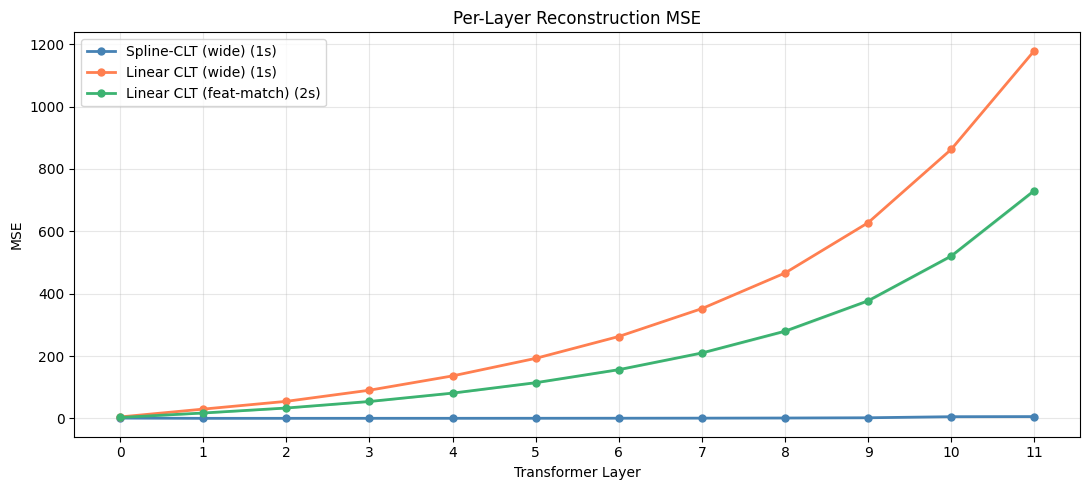

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

for label in VARIANTS:
    seeds = [s for s in AVAILABLE_SEEDS[label] if s in summaries[label]]
    if not seeds:
        continue
    per_layer = np.array([
        summaries[label][s]["reconstruction"]["mse_per_layer"] for s in seeds
    ])  # (n_seeds, n_layers)
    mean = per_layer.mean(axis=0)
    xs   = np.arange(len(mean))
    if per_layer.shape[0] > 1:
        std = per_layer.std(axis=0, ddof=1)
        ax.fill_between(xs, mean - std, mean + std, alpha=0.18, color=COLORS[label])
    ax.plot(xs, mean, marker="o", label=f"{label} ({len(seeds)}s)",
            color=COLORS[label], linewidth=2, markersize=5)

ax.set_xlabel("Transformer Layer")
ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.set_title("Per-Layer Reconstruction MSE")
ax.set_xticks(np.arange(12))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Sparsity & Parameters

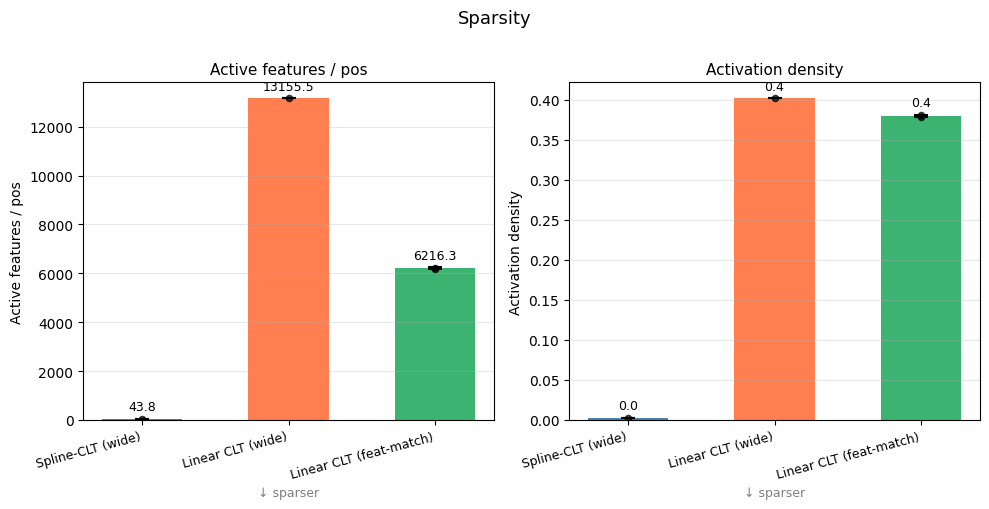


Parameter counts (seed 101):
  Spline-CLT (wide)           : 2,491,819,008
  Linear CLT (wide)           : 2,265,719,808
  Linear CLT (feat-match)     : 1,132,864,512


In [5]:
sparsity_cfg = [
    ("Active features / pos", "active_per_pos",     True),
    ("Activation density",    "activation_density", True),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
x = np.arange(len(VARIANTS))

for ax, (title, key, lower_better) in zip(axes, sparsity_cfg):
    means = [np.mean(recon_values(lbl, key)) for lbl in VARIANTS]
    stds  = [np.std(recon_values(lbl, key), ddof=1) if len(recon_values(lbl, key)) > 1 else 0.0
             for lbl in VARIANTS]
    bars = ax.bar(x, means, 0.55, yerr=stds, capsize=5,
                  color=[COLORS[l] for l in VARIANTS],
                  error_kw={"elinewidth": 1.5, "ecolor": "black", "capthick": 1.5})
    ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(list(VARIANTS.keys()), fontsize=9, rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("\u2193 sparser", fontsize=9, color="grey")
    for i, lbl in enumerate(VARIANTS):
        vals = recon_values(lbl, key)
        ax.scatter([i] * len(vals), vals, color="black", s=20, zorder=5, alpha=0.7)

fig.suptitle("Sparsity", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nParameter counts (seed 101):")
for label in VARIANTS:
    if 101 in summaries[label]:
        n = summaries[label][101]["reconstruction"]["n_params"]
        print(f"  {label:<28}: {n:,}")

## 4. Replacement Fidelity

Top-1 match rate and KL divergence from `prompt_metrics`.

Prompt evaluation error counts (seed 101):
  Spline-CLT (wide)           : 0/60 errors
  Linear CLT (wide)           : 19/41 errors
  Linear CLT (feat-match)     : 0/60 errors


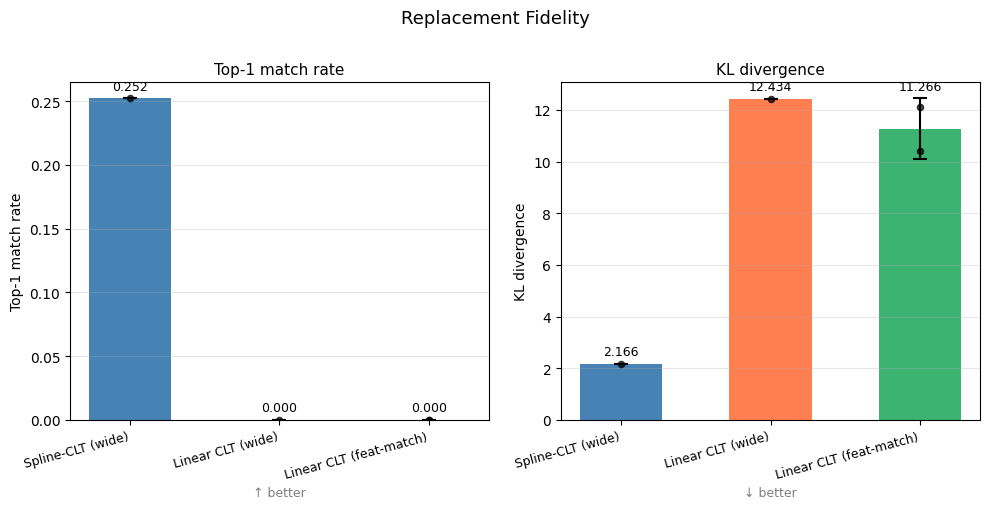

In [6]:
def prompt_values(label: str, key: str) -> list[float]:
    return [summaries[label][s]["prompt_metrics"][key]
            for s in AVAILABLE_SEEDS[label] if s in summaries[label]]

fidelity_cfg = [
    ("Top-1 match rate", "top1_match_rate", False),
    ("KL divergence",    "kl_divergence",   True),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
x = np.arange(len(VARIANTS))

for ax, (title, key, lower_better) in zip(axes, fidelity_cfg):
    means = [np.mean(prompt_values(lbl, key)) for lbl in VARIANTS]
    stds  = [np.std(prompt_values(lbl, key), ddof=1) if len(prompt_values(lbl, key)) > 1 else 0.0
             for lbl in VARIANTS]
    bars = ax.bar(x, means, 0.55, yerr=stds, capsize=5,
                  color=[COLORS[l] for l in VARIANTS],
                  error_kw={"elinewidth": 1.5, "ecolor": "black", "capthick": 1.5})
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(list(VARIANTS.keys()), fontsize=9, rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("\u2193 better" if lower_better else "\u2191 better", fontsize=9, color="grey")
    for i, lbl in enumerate(VARIANTS):
        vals = prompt_values(lbl, key)
        ax.scatter([i] * len(vals), vals, color="black", s=20, zorder=5, alpha=0.7)

# Also show error counts
print("Prompt evaluation error counts (seed 101):")
for label in VARIANTS:
    if 101 in summaries[label]:
        pm = summaries[label][101]["prompt_metrics"]
        print(f"  {label:<28}: {pm['error_count']}/{pm['count']} errors")

fig.suptitle("Replacement Fidelity", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Monosemanticity (Gini Coefficients)

Higher Gini = feature fires more selectively (more monosemantic).

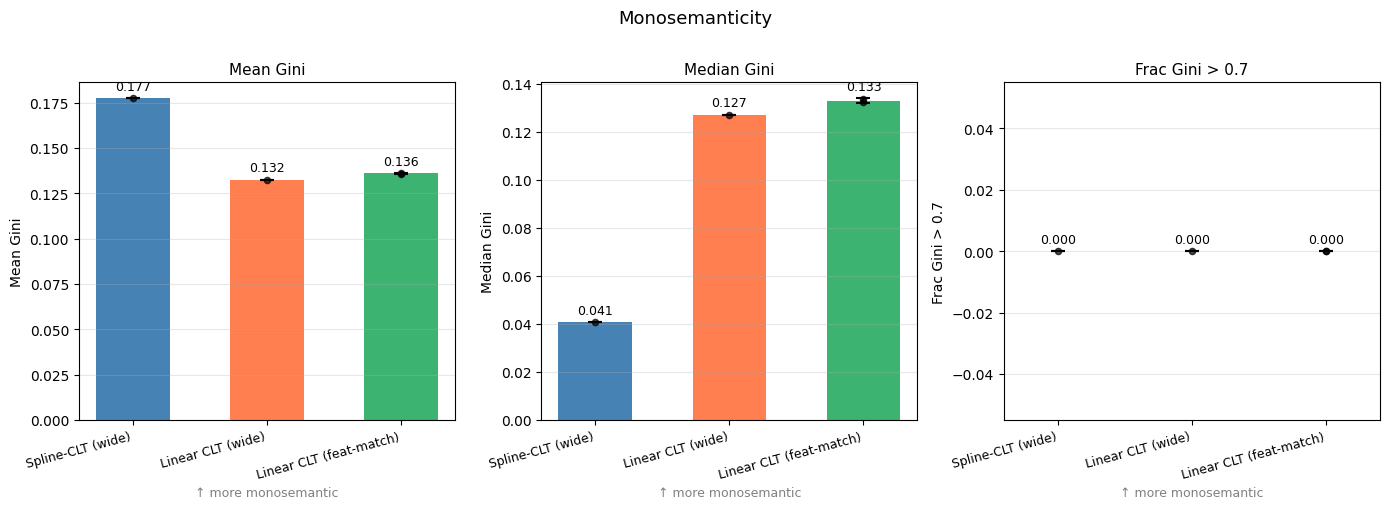

In [7]:
def gini_values(label: str, key: str) -> list[float]:
    return [summaries[label][s]["monosemanticity"][key]
            for s in AVAILABLE_SEEDS[label] if s in summaries[label]]

gini_cfg = [
    ("Mean Gini",         "mean_gini",            False),
    ("Median Gini",       "median_gini",           False),
    ("Frac Gini > 0.7",   "fraction_gini_gt_0_7",  False),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
x = np.arange(len(VARIANTS))

for ax, (title, key, _) in zip(axes, gini_cfg):
    means = [np.mean(gini_values(lbl, key)) for lbl in VARIANTS]
    stds  = [np.std(gini_values(lbl, key), ddof=1) if len(gini_values(lbl, key)) > 1 else 0.0
             for lbl in VARIANTS]
    bars = ax.bar(x, means, 0.55, yerr=stds, capsize=5,
                  color=[COLORS[l] for l in VARIANTS],
                  error_kw={"elinewidth": 1.5, "ecolor": "black", "capthick": 1.5})
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(list(VARIANTS.keys()), fontsize=9, rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("\u2191 more monosemantic", fontsize=9, color="grey")
    for i, lbl in enumerate(VARIANTS):
        vals = gini_values(lbl, key)
        ax.scatter([i] * len(vals), vals, color="black", s=20, zorder=5, alpha=0.7)

fig.suptitle("Monosemanticity", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Circuit Metrics

Graph quality and faithfulness from the paper evaluation prompts.

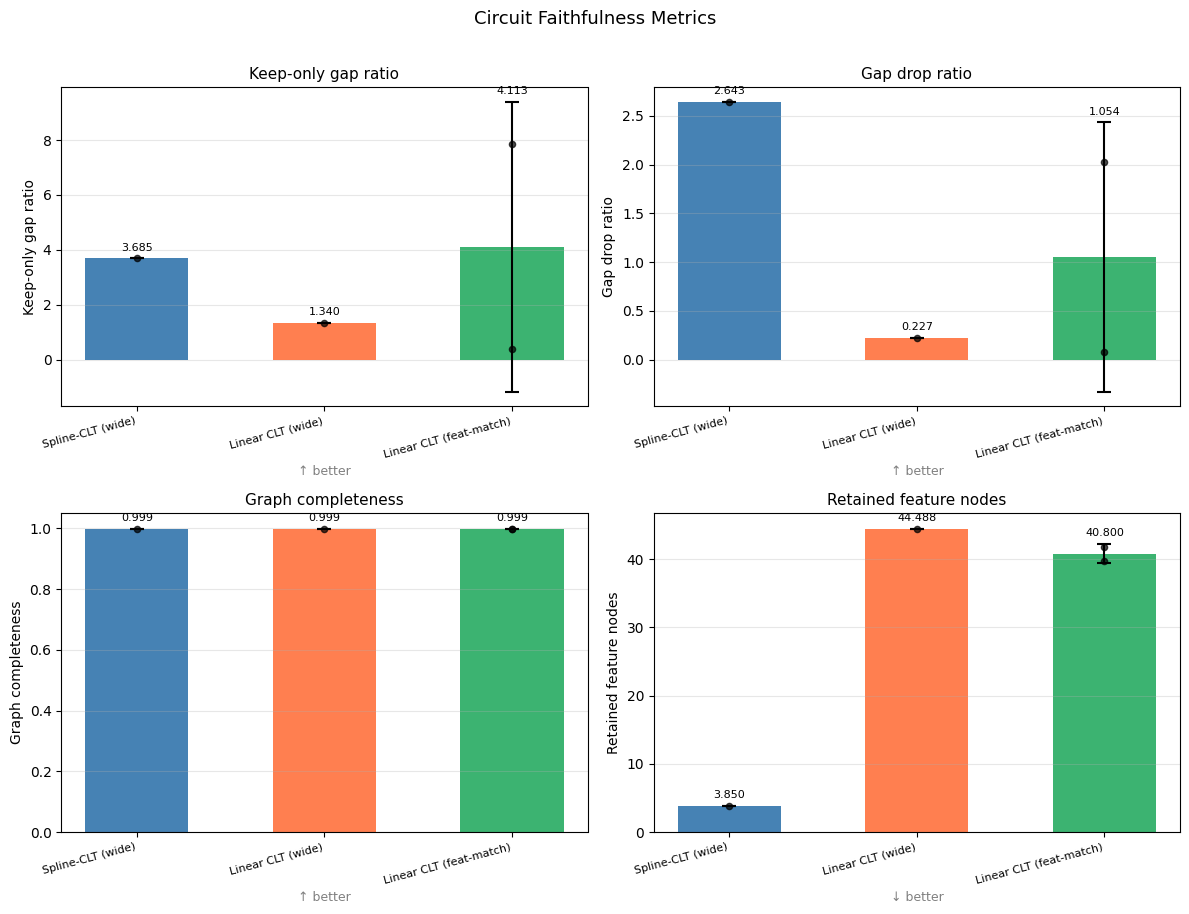

In [8]:
def circuit_values(label: str, key: str) -> list[float]:
    return [summaries[label][s]["circuit_metrics"][key]
            for s in AVAILABLE_SEEDS[label] if s in summaries[label]]

circuit_cfg = [
    ("Keep-only gap ratio",     "keep_only_gap_ratio",          False),
    ("Gap drop ratio",          "gap_drop_ratio",               False),
    ("Graph completeness",      "graph_completeness_score",     False),
    ("Retained feature nodes",  "retained_feature_node_count",  True),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
x = np.arange(len(VARIANTS))

for ax, (title, key, lower_better) in zip(axes.flat, circuit_cfg):
    means = [np.mean(circuit_values(lbl, key)) for lbl in VARIANTS]
    stds  = [np.std(circuit_values(lbl, key), ddof=1) if len(circuit_values(lbl, key)) > 1 else 0.0
             for lbl in VARIANTS]
    bars = ax.bar(x, means, 0.55, yerr=stds, capsize=5,
                  color=[COLORS[l] for l in VARIANTS],
                  error_kw={"elinewidth": 1.5, "ecolor": "black", "capthick": 1.5})
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(list(VARIANTS.keys()), fontsize=8, rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.3)
    direction = "\u2193 better" if lower_better else "\u2191 better"
    ax.set_xlabel(direction, fontsize=9, color="grey")
    for i, lbl in enumerate(VARIANTS):
        vals = circuit_values(lbl, key)
        ax.scatter([i] * len(vals), vals, color="black", s=20, zorder=5, alpha=0.7)

fig.suptitle("Circuit Faithfulness Metrics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Seed Consistency Table

In [9]:
metrics_cfg = [
    ("MSE (total)",      lambda s: s["reconstruction"]["mse_total"],          ".4f"),
    ("Cosine sim",       lambda s: s["reconstruction"]["cosine_similarity"],   ".4f"),
    ("Relative error",   lambda s: s["reconstruction"]["relative_error"],      ".4f"),
    ("Active / pos",     lambda s: s["reconstruction"]["active_per_pos"],      ".1f"),
    ("Density",          lambda s: s["reconstruction"]["activation_density"],  ".5f"),
    ("Top-1 match",      lambda s: s["prompt_metrics"]["top1_match_rate"],     ".3f"),
    ("KL divergence",    lambda s: s["prompt_metrics"]["kl_divergence"],       ".3f"),
    ("Mean Gini",        lambda s: s["monosemanticity"]["mean_gini"],          ".4f"),
    ("Median Gini",      lambda s: s["monosemanticity"]["median_gini"],        ".4f"),
    ("Keep-only gap",    lambda s: s["circuit_metrics"]["keep_only_gap_ratio"],".3f"),
    ("Gap drop",         lambda s: s["circuit_metrics"]["gap_drop_ratio"],     ".3f"),
]

labels = list(VARIANTS.keys())
print(f"{'Metric':<20}" + "".join(f"  {lbl:<34}" for lbl in labels))
print("-" * (20 + len(labels) * 36))

for name, extractor, fmt in metrics_cfg:
    row = f"{name:<20}"
    for lbl in labels:
        vals = [extractor(summaries[lbl][s])
                for s in AVAILABLE_SEEDS[lbl] if s in summaries[lbl]]
        if not vals:
            row += f"  {'(no data)':<34}"
            continue
        per_seed = "  ".join(f"{v:{fmt}}" for v in vals)
        mu = np.mean(vals)
        if len(vals) > 1:
            row += f"  {per_seed}  (\u03bc={mu:{fmt}})"
        else:
            row += f"  {per_seed:<34}"
    print(row)

Metric                Spline-CLT (wide)                   Linear CLT (wide)                   Linear CLT (feat-match)           
--------------------------------------------------------------------------------------------------------------------------------
MSE (total)           1.5130                              354.8774                            214.0727  215.5345  (μ=214.8036)
Cosine sim            0.2063                              0.0477                              0.0555  0.0552  (μ=0.0554)
Relative error        0.4639                              7.1059                              5.5193  5.5341  (μ=5.5267)
Active / pos          43.8                                13155.5                             6196.9  6235.7  (μ=6216.3)
Density               0.00267                             0.40147                             0.37823  0.38060  (μ=0.37941)
Top-1 match           0.252                               0.000                               0.000  0.000  (μ=0.000)
KL diverge

## 8. Scatter: Reconstruction vs Monosemanticity

Each dot = one (variant, seed). Good models: low MSE + high Gini.

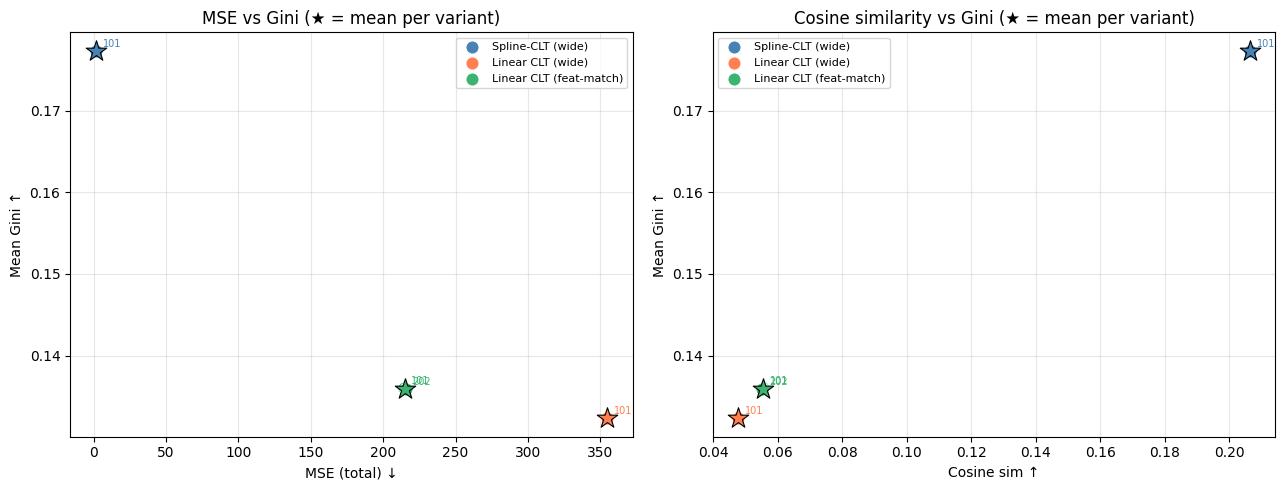

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (xsection, xkey, ysection, ykey, xlabel, ylabel) in zip(axes, [
    ("reconstruction", "mse_total",        "monosemanticity", "mean_gini", "MSE (total) \u2193", "Mean Gini \u2191"),
    ("reconstruction", "cosine_similarity", "monosemanticity", "mean_gini", "Cosine sim \u2191",  "Mean Gini \u2191"),
]):
    for lbl in VARIANTS:
        seeds = [s for s in AVAILABLE_SEEDS[lbl] if s in summaries[lbl]]
        xs = [summaries[lbl][s][xsection][xkey] for s in seeds]
        ys = [summaries[lbl][s][ysection][ykey] for s in seeds]
        ax.scatter(xs, ys, color=COLORS[lbl], s=90, zorder=5, label=lbl,
                   edgecolors="white", linewidths=0.8)
        if xs:
            ax.scatter([np.mean(xs)], [np.mean(ys)], color=COLORS[lbl],
                       s=240, marker="*", zorder=6, edgecolors="black", linewidths=0.8)
        for s, xv, yv in zip(seeds, xs, ys):
            ax.annotate(str(s), (xv, yv), textcoords="offset points",
                        xytext=(5, 3), fontsize=7, color=COLORS[lbl])
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

axes[0].set_title("MSE vs Gini (\u2605 = mean per variant)")
axes[1].set_title("Cosine similarity vs Gini (\u2605 = mean per variant)")
plt.tight_layout()
plt.show()

---
## 9. Spline Analysis — KAN Encoder (seed 101)

Loads the Spline-CLT checkpoint and visualises learned B-spline transfer functions for the top active features.

In [11]:
from spline_clt.kan_transcoder import load_spline_clt
from spline_clt.utils import count_parameters

_spline_ckpt = (RUNS_ROOT / "spline_wide_gpt2"
                / f"seed_{INTERACTIVE_SEED}" / "checkpoints"
                / f"spline_clt_gpt2_wide_seed{INTERACTIVE_SEED}_best")
_linear_ckpt = (RUNS_ROOT / "linear_wide_gpt2"
                / f"seed_{INTERACTIVE_SEED}" / "checkpoints"
                / f"linear_clt_gpt2_wide_seed{INTERACTIVE_SEED}_best")

models = {}
for label, ckpt in [("Spline-CLT (wide)", _spline_ckpt), ("Linear CLT (wide)", _linear_ckpt)]:
    if not ckpt.exists():
        print(f"[MISSING] {label}: {ckpt}")
        continue
    print(f"Loading {label} from {ckpt.name} ...")
    m = load_spline_clt(str(ckpt), device=DEVICE, dtype=DTYPE)
    m.eval()
    models[label] = m
    print(f"  encoder_type={m.encoder_type}  d_transcoder={m.d_transcoder}"
          f"  params={count_parameters(m):,}")

kan_model    = models.get("Spline-CLT (wide)")
linear_model = models.get("Linear CLT (wide)")

Loading Spline-CLT (wide) from spline_clt_gpt2_wide_seed101_best ...
  encoder_type=kan  d_transcoder=16384  params=2,491,819,008
Loading Linear CLT (wide) from linear_clt_gpt2_wide_seed101_best ...
  encoder_type=linear  d_transcoder=32768  params=2,265,719,808


In [12]:
from experiments.analyze_splines import collect_feature_stats, extract_spline_curve, top_input_dims
from spline_clt.training.data import ActivationDataset

if kan_model is None:
    print("Spline-CLT not loaded — skipping spline analysis.")
    dataset = top_features = freq = None
else:
    print(f"Loading dataset from {DATA_DIR} ...")
    dataset = ActivationDataset.load(DATA_DIR, max_samples=250)
    print(f"  {len(dataset)} sequences loaded")

    print("Collecting KAN feature statistics ...")
    spline_stats = collect_feature_stats(kan_model, dataset, DEVICE, torch.float32, n_samples=200)
    freq = spline_stats["activation_frequency"]  # (n_layers, d_transcoder)

    flat_freq   = freq.reshape(-1)
    top_indices = flat_freq.topk(N_SPLINE_FEATURES).indices
    top_features = [
        (int(idx // kan_model.d_transcoder), int(idx % kan_model.d_transcoder))
        for idx in top_indices
    ]
    print(f"Top {N_SPLINE_FEATURES} features: {top_features}")

Loading dataset from /home/sureshm/circuit-tracer/results/paper/neurips_wide_gpt2/shared/activations/gpt2 ...
  250 sequences loaded
Top 6 features: [(10, 757), (10, 2627), (10, 12180), (10, 11955), (10, 10745), (10, 7072)]


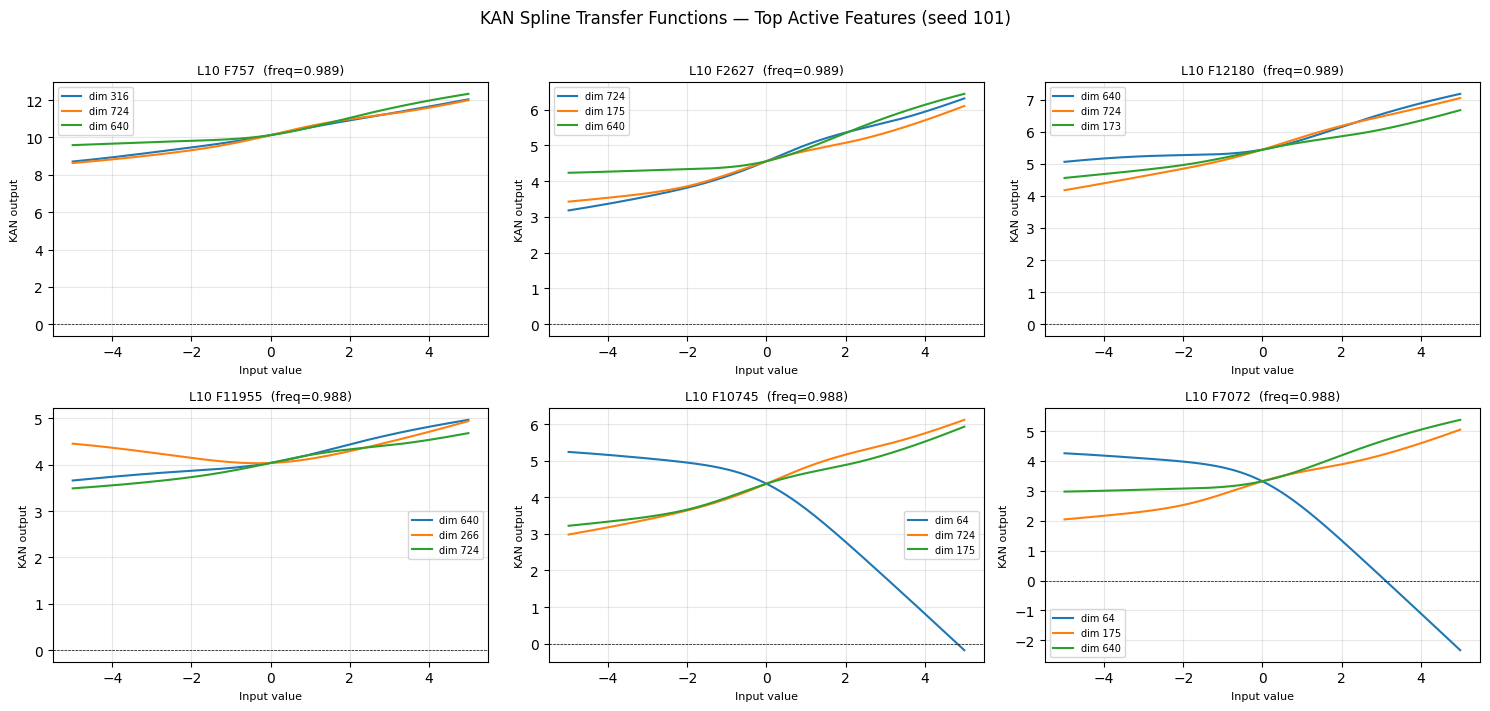

Nonlinearity (residual/variance — higher = more nonlinear):
  L10 F7072    0.1301  <- nonlinear
  L10 F10745   0.1185  <- nonlinear
  L10 F12180   0.1153  <- nonlinear
  L10 F11955   0.0525  <- nonlinear
  L10 F2627    0.0087
  L10 F757     0.0064


In [13]:
if kan_model is not None and top_features is not None:
    n_cols = 3
    n_rows = int(np.ceil(N_SPLINE_FEATURES / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=False)

    for plot_idx, (layer_id, feature_id) in enumerate(top_features):
        ax = axes[plot_idx // n_cols][plot_idx % n_cols]
        f_freq = freq[layer_id, feature_id].item()
        try:
            dims = top_input_dims(kan_model, layer_id, feature_id, top_k=3)
            for dim in dims:
                t_vals, curve = extract_spline_curve(kan_model, layer_id, feature_id, dim, device=DEVICE)
                ax.plot(t_vals, curve, label=f"dim {dim}", linewidth=1.5)
            ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
            ax.set_title(f"L{layer_id} F{feature_id}  (freq={f_freq:.3f})", fontsize=9)
            ax.set_xlabel("Input value", fontsize=8); ax.set_ylabel("KAN output", fontsize=8)
            ax.legend(fontsize=7); ax.grid(alpha=0.3)
        except Exception as e:
            ax.text(0.5, 0.5, str(e), ha="center", va="center",
                    transform=ax.transAxes, fontsize=8, color="red")
            ax.set_title(f"L{layer_id} F{feature_id}", fontsize=9)

    for i in range(N_SPLINE_FEATURES, n_rows * n_cols):
        axes[i // n_cols][i % n_cols].set_visible(False)

    fig.suptitle(f"KAN Spline Transfer Functions — Top Active Features (seed {INTERACTIVE_SEED})",
                 fontsize=12, y=1.01)
    plt.tight_layout(); plt.show()

    # Nonlinearity scores
    scores = []
    for layer_id, feature_id in top_features:
        try:
            dims = top_input_dims(kan_model, layer_id, feature_id, top_k=1)
            t_vals, curve = extract_spline_curve(kan_model, layer_id, feature_id, dims[0],
                                                  n_points=200, device=DEVICE)
            coeffs = np.polyfit(t_vals, curve, 1)
            residual = np.mean((curve - np.polyval(coeffs, t_vals)) ** 2)
            nonlin = residual / (np.var(curve) + 1e-8)
            scores.append((layer_id, feature_id, nonlin))
        except Exception:
            continue

    scores.sort(key=lambda x: x[2], reverse=True)
    print("Nonlinearity (residual/variance — higher = more nonlinear):")
    for layer_id, feature_id, score in scores:
        tag = "  <- nonlinear" if score > 0.05 else ""
        print(f"  L{layer_id} F{feature_id:<6}  {score:.4f}{tag}")

## 10. Circuit Tracing on a Prompt (seed 101)

In [ ]:
from experiments.run_circuit import collect_activations_for_prompt
from attribution.causal import build_attribution_graph

attributions = {}

if not models:
    print("No models loaded — skipping circuit tracing.")
else:
    first_model = next(iter(models.values()))
    print(f"Prompt: {PROMPT!r}")
    mlp_inputs, mlp_outputs, tokens, lm = collect_activations_for_prompt(
        model_name="gpt2",
        prompt=PROMPT,
        n_layers=first_model.n_layers,
        device=DEVICE,
        feature_input_hook=first_model.feature_input_hook,
        feature_output_hook=first_model.feature_output_hook,
    )
    mlp_inputs  = mlp_inputs.to(dtype=DTYPE)
    mlp_outputs = mlp_outputs.to(dtype=DTYPE)
    print(f"Tokens: {tokens}")

    # Select top logit tokens for feature->logit edges
    with torch.no_grad():
        logits = lm(PROMPT).squeeze(0)
        probs = torch.softmax(logits[-1].float(), dim=-1)
        top_logit_ids = probs.topk(8).indices

    for label, model in models.items():
        print(f"Running causal attribution for {label} ...")
        with torch.no_grad():
            attr = build_attribution_graph(
                model, mlp_inputs, max_features=MAX_FEATURES,
                W_U=lm.W_U, logit_token_ids=top_logit_ids,
            )
        attributions[label] = attr
        n_active = len(attr['active_features'])
        adj_shape = attr['adjacency_matrix'].shape
        print(f"  {n_active} active features, adjacency matrix: {adj_shape}")

    del lm
    torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

Prompt: 'The Eiffel Tower is located in'
Loading gpt2 with TransformerLens...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
Running forward pass: 9 tokens...
Tokens: ['<|endoftext|>', 'The', ' E', 'iff', 'el', ' Tower', ' is', ' located', ' in']
Running causal attribution for Spline-CLT (wide) ...


Ablating features: 100%|██████████| 64/64 [00:00<00:00, 106.19it/s]


  64 active features, adjacency matrix: torch.Size([189, 189])
Running causal attribution for Linear CLT (wide) ...


Ablating features:   0%|          | 0/64 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 23.97 GiB. GPU 0 has a total capacity of 95.00 GiB of which 18.25 GiB is free. Process 949521 has 6.47 GiB memory in use. Including non-PyTorch memory, this process has 70.27 GiB memory in use. Of the allocated memory 43.84 GiB is allocated by PyTorch, and 25.67 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 

In [ ]:
if attributions:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Active features by layer
    ax = axes[0]
    n_layers = first_model.n_layers
    x = np.arange(n_layers)
    bar_w = 0.35
    offsets = np.linspace(-bar_w, bar_w, len(attributions))
    for offset, (label, attr) in zip(offsets, attributions.items()):
        layers = attr["active_features"][:, 0].cpu().numpy()
        counts = np.bincount(layers, minlength=n_layers)
        ax.bar(x + offset, counts, width=bar_w, label=label,
               color=COLORS.get(label, "grey"), alpha=0.85)
    ax.set_xlabel("Transformer Layer"); ax.set_ylabel("Active Feature Count")
    ax.set_title(f"Active Features per Layer\n{PROMPT!r}")
    ax.set_xticks(x); ax.legend(); ax.grid(alpha=0.3, axis="y")

    # Top-8 features table
    ax = axes[1]; ax.axis("off")
    TOP_K = 8
    rows = [["Rank", "Model", "Layer", "Pos", "Feat", "Act", "Token"]]
    for label, attr in attributions.items():
        active = attr["active_features"]
        values = attr["activation_values"]
        for rank, i in enumerate(values.abs().argsort(descending=True)[:TOP_K], 1):
            layer = active[i, 0].item(); pos = active[i, 1].item(); feat = active[i, 2].item()
            tok = tokens[pos] if pos < len(tokens) else "?"
            rows.append([str(rank), label[:12], str(layer), str(pos),
                         str(feat), f"{values[i].item():.1f}", repr(tok)])
    tbl = ax.table(cellText=rows[1:], colLabels=rows[0], loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.2)
    ax.set_title(f"Top {TOP_K} Features per Model (seed {INTERACTIVE_SEED})", pad=14)

    plt.tight_layout(); plt.show()

---
## 11. Shapley Attribution (Optional — Slow)

In [ ]:
if not RUN_SHAPLEY:
    print("Skipping Shapley attribution (RUN_SHAPLEY=False).")
    print("Set RUN_SHAPLEY=True in the configuration cell to run this section.")

In [ ]:
shapley_results = {}

if RUN_SHAPLEY:
    from attribution.shapley import shapley_attribution

    if not attributions:
        print("No causal attributions found — re-run Section 10 first.")
    else:
        for label, model in models.items():
            n_active = len(attributions[label]["active_features"])
            cap = min(MAX_FEATURES, 32)
            print(f"Running Shapley for {label}  "
                  f"(active={n_active}, cap={cap}, samples={SHAPLEY_SAMPLES}) ...")
            with torch.no_grad():
                shap = shapley_attribution(
                    model, mlp_inputs,
                    target="reconstruction",
                    n_samples=SHAPLEY_SAMPLES,
                    max_features=cap,
                    antithetic=True,
                )
            shapley_results[label] = shap
            total = shap["shapley_values"].sum().item()
            print(f"  Sum of Shapley values = {total:.4f}  "
                  f"(= reconstruction improvement over empty baseline)")
        print("Done.")

In [ ]:
if RUN_SHAPLEY and shapley_results:
    n_models = len(shapley_results)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5), sharey=False)
    if n_models == 1:
        axes = [axes]

    for ax, (label, shap) in zip(axes, shapley_results.items()):
        sv     = shap["shapley_values"].cpu().numpy()
        active = shap["active_features"].cpu().numpy()
        sorted_idx = np.argsort(sv)[::-1][:20]

        top_sv     = sv[sorted_idx]
        top_labels = [f"L{active[i,0]}F{active[i,2]}@p{active[i,1]}"
                      for i in sorted_idx]
        bar_colors = [COLORS.get(label, 'steelblue') if v >= 0 else 'coral'
                      for v in top_sv]

        ax.barh(range(len(top_sv)), top_sv[::-1], color=bar_colors[::-1])
        ax.set_yticks(range(len(top_sv)))
        ax.set_yticklabels(top_labels[::-1], fontsize=7)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Shapley value (reconstruction MSE reduction)')
        ax.set_title(f'{label}\nTop-20 Features by Shapley Value (seed {INTERACTIVE_SEED})')
        ax.grid(alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

In [ ]:
if RUN_SHAPLEY and shapley_results and attributions:
    n_models = len(shapley_results)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), sharey=False)
    if n_models == 1:
        axes = [axes]

    for ax, (label, shap) in zip(axes, shapley_results.items()):
        sv     = shap["shapley_values"].cpu().numpy()
        causal = attributions[label]["activation_values"].cpu().numpy()
        n      = min(len(sv), len(causal))

        ax.scatter(causal[:n], sv[:n], alpha=0.5, s=20,
                   color=COLORS.get(label, 'grey'))
        ax.set_xlabel('Activation value (causal)')
        ax.set_ylabel('Shapley value')
        ax.set_title(f'{label}\nCausal Activation vs Shapley Value')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 12. MACAG Game Results

MACAG runs two evidence-allocation games over the circuit graph:

- **Game 1** (`faithfulness`): find a minimal evidence set that faithfully explains the model's prediction.
- **Game 2** (`contrastive`): find evidence that distinguishes target from foil.

In [ ]:
import glob as _glob

# macag_records[label][seed] = list of records
macag_records: dict[str, dict[int, list[dict]]] = {}

for label, variant_dir in VARIANTS.items():
    macag_records[label] = {}
    for seed in AVAILABLE_SEEDS[label]:
        path = RUNS_ROOT / variant_dir / f"seed_{seed}" / "macag" / "macag_records.jsonl"
        if path.exists():
            records = [json.loads(l) for l in path.open()]
            macag_records[label][seed] = [r for r in records if r.get('status', 'ok') == 'ok']
        else:
            macag_records[label][seed] = []

for label in VARIANTS:
    seeds = AVAILABLE_SEEDS[label]
    g1 = sum(len([r for r in macag_records[label].get(s, []) if r.get('record_type')=='macag_game1'])
             for s in seeds)
    g2 = sum(len([r for r in macag_records[label].get(s, []) if r.get('record_type')=='macag_game2'])
             for s in seeds)
    print(f"{label:30s}  game1={g1:3d}  game2={g2:3d}  seeds={seeds}")

In [ ]:
# ── helpers ──────────────────────────────────────────────────────────────
def macag_metric_values(label: str, game: str, metric: str,
                         run_name: str | None = None) -> list[float]:
    """Collect per-(seed, prompt) metric values for one variant."""
    vals: list[float] = []
    for seed in AVAILABLE_SEEDS[label]:
        for r in macag_records[label].get(seed, []):
            if r.get('record_type') != game:
                continue
            if run_name and r.get('run_name') != run_name:
                continue
            v = r.get(metric)
            if v is not None:
                vals.append(float(v))
    return vals

def bar_group(ax, metrics_cfg, game, run_name=None, title=''):
    """Grouped bar chart: x=metric, groups=variant."""
    n_metrics = len(metrics_cfg)
    n_variants = len(VARIANTS)
    bar_w = 0.7 / n_variants
    x = np.arange(n_metrics)

    for vi, label in enumerate(VARIANTS):
        offset = (vi - n_variants / 2 + 0.5) * bar_w
        means, errs = [], []
        for _, metric in metrics_cfg:
            vals = macag_metric_values(label, game, metric, run_name)
            if vals:
                means.append(np.mean(vals))
                errs.append(np.std(vals) / max(1, len(vals)) ** 0.5)
            else:
                means.append(float('nan'))
                errs.append(0.0)
        bars = ax.bar(x + offset, means, bar_w, label=label,
                      color=COLORS.get(label, 'grey'), alpha=0.85,
                      yerr=errs, capsize=3, error_kw={'linewidth': 1})
        for xi, (_, metric) in enumerate(metrics_cfg):
            for seed in AVAILABLE_SEEDS[label]:
                seed_vals = [r.get(metric, float('nan'))
                             for r in macag_records[label].get(seed, [])
                             if r.get('record_type') == game
                             and (run_name is None or r.get('run_name') == run_name)]
                if seed_vals:
                    ax.scatter([xi + offset] * len(seed_vals), seed_vals,
                               s=6, color=COLORS.get(label, 'grey'),
                               alpha=0.35, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([m for m, _ in metrics_cfg], fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, axis='y')
    ax.set_ylim(bottom=0)

# ── Game 1 ────────────────────────────────────────────────────────────────
g1_metrics = [
    ('Faithfulness', 'faithfulness'),
    ('Utility',      'utility'),
    ('Necessity',    'necessity'),
    ('Sufficiency',  'sufficiency'),
    ('Evidence size','evidence_size'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bar_group(axes[0], g1_metrics, 'macag_game1', run_name='faithful_eps_0_10',
          title='Game 1 — Faithful Evidence (\u03b5=0.10)\nmean \u00b1 SEM across seeds \u00d7 prompts')
bar_group(axes[1], g1_metrics, 'macag_game1', run_name='faithful_eps_0_05',
          title='Game 1 — Faithful Evidence (\u03b5=0.05)\nmean \u00b1 SEM across seeds \u00d7 prompts')
plt.tight_layout()
plt.show()

In [ ]:
g2_metrics = [
    ('Faithfulness', 'faithfulness'),
    ('Utility',      'utility'),
    ('Necessity',    'necessity'),
    ('Sufficiency',  'sufficiency'),
    ('Overlap rate', 'overlap_rate'),
    ('Evidence size','evidence_size'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bar_group(axes[0], g2_metrics, 'macag_game2',
          title='Game 2 — Contrastive Evidence\nmean \u00b1 SEM across seeds \u00d7 prompts')

# Oracle efficiency
ax = axes[1]
games_cfg = [
    ('G1 \u03b5=0.10', 'macag_game1', 'faithful_eps_0_10'),
    ('G1 \u03b5=0.05', 'macag_game1', 'faithful_eps_0_05'),
    ('G2 contrast', 'macag_game2', None),
]
n_games = len(games_cfg)
n_variants = len(VARIANTS)
bar_w = 0.7 / n_variants
x = np.arange(n_games)

for vi, label in enumerate(VARIANTS):
    offset = (vi - n_variants / 2 + 0.5) * bar_w
    means = []
    for _, game, run_name in games_cfg:
        vals = macag_metric_values(label, game, 'oracle_calls', run_name)
        means.append(np.mean(vals) if vals else float('nan'))
    ax.bar(x + offset, means, bar_w, label=label,
           color=COLORS.get(label, 'grey'), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([g for g, _, _ in games_cfg])
ax.set_ylabel('Mean oracle calls')
ax.set_title('Oracle Calls per Game\n(lower = more cache-efficient)')
ax.legend(fontsize=7)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Per-family breakdown: faithfulness by family for Game 1 (eps=0.10)
families = ['ioi', 'factual', 'arithmetic']
fig, axes = plt.subplots(1, len(families), figsize=(15, 4), sharey=True)

for ax, family in zip(axes, families):
    for vi, label in enumerate(VARIANTS):
        vals_by_seed = []
        for seed in AVAILABLE_SEEDS[label]:
            seed_vals = [
                r.get('faithfulness', 0.0)
                for r in macag_records[label].get(seed, [])
                if r.get('record_type') == 'macag_game1'
                and r.get('run_name') == 'faithful_eps_0_10'
                and r.get('family') == family
            ]
            if seed_vals:
                vals_by_seed.append(np.mean(seed_vals))
        if vals_by_seed:
            mean_val = np.mean(vals_by_seed)
            sem_val  = np.std(vals_by_seed) / max(1, len(vals_by_seed)) ** 0.5
            ax.bar(vi, mean_val, 0.65, color=COLORS.get(label, 'grey'),
                   alpha=0.85, yerr=sem_val, capsize=4,
                   error_kw={'linewidth': 1}, label=label)
            ax.scatter([vi] * len(vals_by_seed), vals_by_seed,
                       s=18, color=COLORS.get(label, 'grey'), zorder=3, alpha=0.7)
        else:
            ax.bar(vi, 0, 0.65, color='lightgrey', alpha=0.5,
                   label=f'{label} (no data)')

    ax.set_xticks(range(len(VARIANTS)))
    ax.set_xticklabels([l[:12] for l in VARIANTS], rotation=20, ha='right', fontsize=8)
    ax.set_title(f'{family.capitalize()}\nGame 1 Faithfulness (\u03b5=0.10)', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3, axis='y')
    if ax is axes[0]:
        ax.set_ylabel('Mean faithfulness')

axes[-1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.suptitle('Game 1 Faithfulness by Prompt Family (\u03b5=0.10)', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Per-prompt solved status — heatmap of faithfulness per prompt per variant
all_prompts = sorted(set(
    r['prompt_id']
    for label in VARIANTS
    for seed in AVAILABLE_SEEDS[label]
    for r in macag_records[label].get(seed, [])
    if r.get('record_type') == 'macag_game1' and r.get('run_name') == 'faithful_eps_0_10'
))

if all_prompts:
    labels = list(VARIANTS.keys())
    matrix = np.full((len(labels), len(all_prompts)), np.nan)
    for vi, label in enumerate(labels):
        for pi, pid in enumerate(all_prompts):
            seed_vals = []
            for seed in AVAILABLE_SEEDS[label]:
                seed_faith = [
                    r['faithfulness']
                    for r in macag_records[label].get(seed, [])
                    if r.get('record_type') == 'macag_game1'
                    and r.get('run_name') == 'faithful_eps_0_10'
                    and r.get('prompt_id') == pid
                ]
                if seed_faith:
                    seed_vals.append(np.mean(seed_faith))
            if seed_vals:
                matrix[vi, pi] = np.mean(seed_vals)

    fig, ax = plt.subplots(figsize=(max(12, len(all_prompts) * 0.45), 3))
    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1,
                   interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Mean faithfulness (\u03b5=0.10)', fraction=0.02)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xticks(range(len(all_prompts)))
    ax.set_xticklabels(all_prompts, rotation=45, ha='right', fontsize=6)
    ax.set_title('Game 1 Faithfulness per Prompt (mean across seeds)\nGreen = circuit explained, Red = unexplained')
    plt.tight_layout()
    plt.show()
else:
    print('No Game 1 records found — run MACAG first.')

In [ ]:
# Evidence size distribution & seed stability
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: evidence_size distribution per variant and game
ax = axes[0]
positions, tick_labels, tick_pos = [], [], []
base = 0
for label in VARIANTS:
    for gi, (game, run_name) in enumerate([
        ('macag_game1', 'faithful_eps_0_10'),
        ('macag_game2', None),
    ]):
        vals = macag_metric_values(label, game, 'evidence_size', run_name)
        pos = base + gi
        if vals:
            ax.boxplot(vals, positions=[pos], widths=0.6,
                       patch_artist=True, medianprops={'color': 'black'},
                       boxprops={'facecolor': COLORS.get(label, 'grey'), 'alpha': 0.7},
                       whiskerprops={'linewidth': 1}, capprops={'linewidth': 1},
                       flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
        else:
            ax.scatter([pos], [0], s=20, color='lightgrey', marker='x')
    tick_pos.append(base + 0.5)
    tick_labels.append(label[:14])
    base += 3

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Evidence set size (# features)')
ax.set_title('Evidence Set Size Distribution\nGame 1 (left) vs Game 2 (right) per variant')
ax.grid(alpha=0.3, axis='y')

# Right: seed-to-seed Jaccard stability for Game 1 (only meaningful with >1 seed)
ax = axes[1]
for vi, label in enumerate(VARIANTS):
    seeds = AVAILABLE_SEEDS[label]
    seed_evidence: dict[int, dict[str, set]] = {}
    for seed in seeds:
        seed_evidence[seed] = {
            r['prompt_id']: set(r.get('evidence_nodes', []))
            for r in macag_records[label].get(seed, [])
            if r.get('record_type') == 'macag_game1'
            and r.get('run_name') == 'faithful_eps_0_10'
        }
    jaccards = []
    for i in range(len(seeds)):
        for j in range(i + 1, len(seeds)):
            ev_i, ev_j = seed_evidence[seeds[i]], seed_evidence[seeds[j]]
            for pid in set(ev_i) & set(ev_j):
                a, b = ev_i[pid], ev_j[pid]
                union = a | b
                jaccards.append(len(a & b) / len(union) if union else 1.0)
    if jaccards:
        ax.bar(vi, np.mean(jaccards), 0.65,
               color=COLORS.get(label, 'grey'), alpha=0.85,
               yerr=np.std(jaccards), capsize=4,
               error_kw={'linewidth': 1})
        ax.scatter([vi] * len(jaccards), jaccards,
                   s=6, color=COLORS.get(label, 'grey'), alpha=0.3, zorder=3)
    else:
        ax.bar(vi, 0, 0.65, color='lightgrey', alpha=0.5)
        if len(seeds) < 2:
            ax.text(vi, 0.02, '1 seed', ha='center', fontsize=7, color='grey')

ax.set_xticks(range(len(VARIANTS)))
ax.set_xticklabels(list(VARIANTS.keys()), rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Mean pairwise Jaccard')
ax.set_ylim(0, 1.05)
ax.set_title('Seed Stability of Game 1 Evidence Sets\n(Jaccard similarity across seed pairs)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 13. Summary Table

In [ ]:
print("\n" + "=" * 90)
print("  Spline-CLT vs Linear CLT (Wide) — Aggregate Summary".center(90))
print("=" * 90)

summary_rows = [
    ("--- Reconstruction ---",       None),
    ("MSE (total) \u2193",           ("reconstruction",   "mse_total")),
    ("Cosine similarity \u2191",      ("reconstruction",   "cosine_similarity")),
    ("Relative error \u2193",         ("reconstruction",   "relative_error")),
    ("--- Sparsity ---",              None),
    ("Active features / pos \u2193",  ("reconstruction",   "active_per_pos")),
    ("Activation density \u2193",     ("reconstruction",   "activation_density")),
    ("--- Fidelity ---",              None),
    ("Top-1 match rate \u2191",       ("prompt_metrics",   "top1_match_rate")),
    ("KL divergence \u2193",          ("prompt_metrics",   "kl_divergence")),
    ("--- Monosemanticity ---",       None),
    ("Mean Gini \u2191",              ("monosemanticity",  "mean_gini")),
    ("Median Gini \u2191",            ("monosemanticity",  "median_gini")),
    ("Frac Gini > 0.7 \u2191",        ("monosemanticity",  "fraction_gini_gt_0_7")),
    ("--- Circuit ---",               None),
    ("Keep-only gap ratio \u2191",    ("circuit_metrics",  "keep_only_gap_ratio")),
    ("Gap drop ratio \u2191",         ("circuit_metrics",  "gap_drop_ratio")),
]

labels = list(VARIANTS.keys())
col_w  = 28
hdr = f"  {'Metric':<36}" + "".join(f"{l:>{col_w}}" for l in labels)
print(hdr)
print("  " + "-" * (len(hdr) - 2))

for name, key_path in summary_rows:
    if key_path is None:
        print(f"\n  {name}")
        continue
    section, key = key_path
    row = f"  {name:<36}"
    for lbl in labels:
        vals = [summaries[lbl][s][section][key]
                for s in AVAILABLE_SEEDS[lbl] if s in summaries[lbl]]
        if not vals:
            row += f"{'(no data)':>{col_w}}"
            continue
        mu = np.mean(vals)
        if len(vals) > 1:
            std = np.std(vals, ddof=1)
            row += f"{mu:>{col_w//2}.4f} \u00b1 {std:<{col_w//2-3}.4f}"
        else:
            row += f"{mu:>{col_w}.4f}"
    print(row)

print("\n" + "=" * 90)
for lbl in labels:
    seeds = AVAILABLE_SEEDS[lbl]
    n_params = summaries[lbl].get(seeds[0], {}).get("reconstruction", {}).get("n_params", "?")
    print(f"  {lbl:<28}  seeds={seeds}  n_params={n_params:,}" if isinstance(n_params, int)
          else f"  {lbl:<28}  seeds={seeds}")